In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns

# 1. Data collection

In [23]:
student_dataset = pd.read_csv('student_exam_scores.csv')
student_dataset

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [24]:
selected_columns = ['hours_studied', 'sleep_hours', 'attendance_percent', 'exam_score']

In [25]:
student_df = student_dataset[selected_columns]
student_df

,hours_studied,sleep_hours,attendance_percent,exam_score
0,8.0,8.8,72.1,30.2
1,1.3,8.6,60.7,25.0
2,4.0,8.2,73.7,35.8
3,3.5,4.8,95.1,34.0
4,9.1,6.4,89.8,40.3
...,...,...,...,...
195,10.5,5.4,94.0,42.7
196,7.1,6.1,85.1,40.4
197,1.6,6.9,63.8,28.2
198,12.0,7.3,50.5,42.0


# 2. Analysis of features' relationships with exam_score

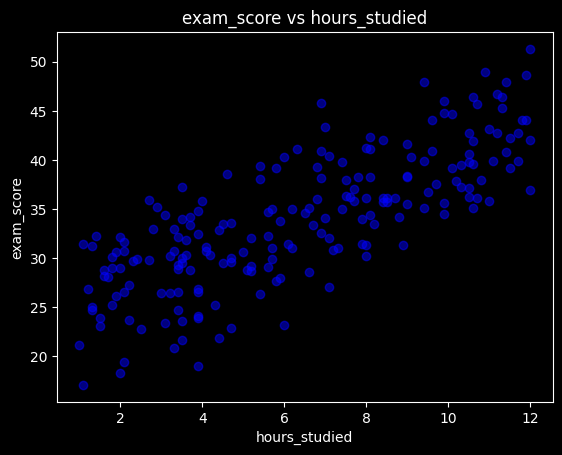

In [26]:
plt.scatter(student_df['hours_studied'], student_df['exam_score'],color = 'blue', alpha=0.5 )
plt.xlabel("hours_studied")
plt.ylabel("exam_score")
plt.title("exam_score vs hours_studied")
plt.show()

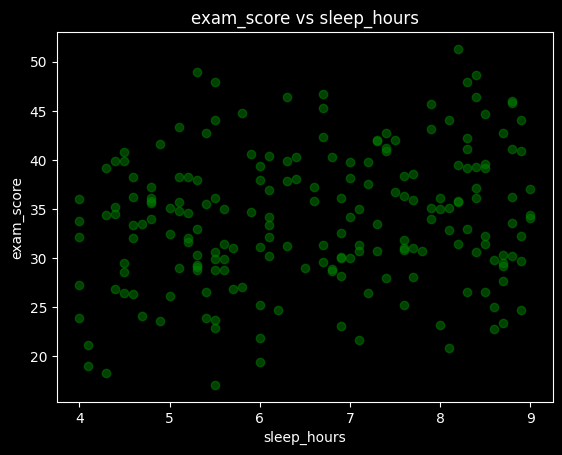

In [27]:
plt.scatter(student_df['sleep_hours'], student_df['exam_score'],color = 'green', alpha=0.5 )
plt.xlabel("sleep_hours")
plt.ylabel("exam_score")
plt.title("exam_score vs sleep_hours")
plt.show()

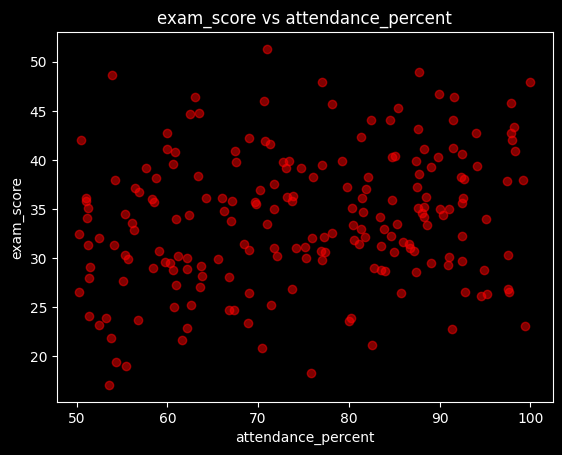

In [28]:
plt.scatter(student_df['attendance_percent'], student_df['exam_score'],color = 'red', alpha=0.5 )
plt.xlabel("attendance_percent")
plt.ylabel("exam_score")
plt.title("exam_score vs attendance_percent")
plt.show()

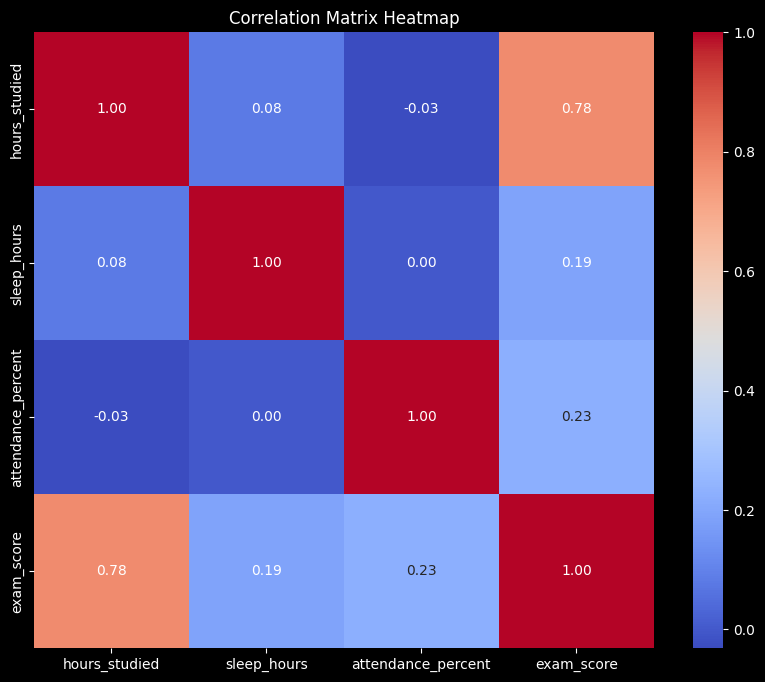

In [39]:
''' heat map of all the features '''
plt.figure(figsize=(10, 8))
correlation_matrix = student_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

# 3.Preparing the data

In [29]:
X = student_df[['hours_studied', 'sleep_hours', 'attendance_percent']]
Y = student_df['exam_score']

In [30]:
X

,hours_studied,sleep_hours,attendance_percent
0,8.0,8.8,72.1
1,1.3,8.6,60.7
2,4.0,8.2,73.7
3,3.5,4.8,95.1
4,9.1,6.4,89.8
...,...,...,...
195,10.5,5.4,94.0
196,7.1,6.1,85.1
197,1.6,6.9,63.8
198,12.0,7.3,50.5


In [31]:
Y

0      30.2
1      25.0
2      35.8
3      34.0
4      40.3
       ... 
195    42.7
196    40.4
197    28.2
198    42.0
199    37.8
Name: exam_score, Length: 200, dtype: float64

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Training the model

In [33]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 5. Make prediction

In [34]:
Y_pred = model.predict(X_test)

In [36]:
print("Comparison of Actual vs Predicted exam_score")
for actual, predicted in list(zip(Y_test[:10], Y_pred[:10])):
    print(f"actual: {round(actual,2)} | predicted: {round(predicted,2)}")


Comparison of Actual vs Predicted exam_score
actual: 28.7| predicted: 33.39
actual: 34.1| predicted: 33.29
actual: 34.5| predicted: 36.53
actual: 29.5| predicted: 30.29
actual: 36.1| predicted: 38.81
actual: 46.4| predicted: 43.67
actual: 23.9| predicted: 26.43
actual: 45.3| predicted: 43.35
actual: 44.8| predicted: 38.09
actual: 31.8| predicted: 30.74


In [37]:
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("R2 :", r2_score(Y_test, Y_pred))

MSE: 14.371927686788586
R2 : 0.729189737973198


# chart to show the difference between the actual and predicted exam_score

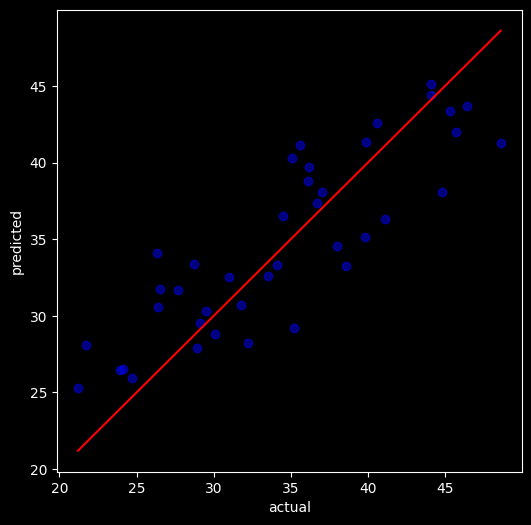

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred, color = 'blue', alpha=0.5)

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color = "red")
plt.xlabel("actual")
plt.ylabel("predicted")
plt.show()